In [124]:
import pandas as pd
import os, sys, re
import numpy as np
import torch.nn as nn
from sklearn.feature_selection import SelectKBest, f_regression
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
import copy
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


# Import Dataset and Tidy

In [125]:
train_data = pd.read_csv("./data/covid.train.csv")
test_data = pd.read_csv("./data/covid.test.csv")

In [126]:
test_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,shop.2,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,52.071090,8.624001,29.374792,5.391413,2.754804,19.695098,13.685645,24.747837,66.194950,44.873473
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58.742461,21.720187,41.375784,9.450179,3.150088,22.075715,17.302077,23.559622,57.015009,38.372829
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59.109045,20.123959,40.072556,8.781522,2.888209,23.920870,18.342506,24.993341,55.291498,38.907257
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.442267,16.083529,36.977612,5.199286,2.575347,21.073800,12.087171,18.608723,67.036197,43.142779
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.588783,19.503010,42.631236,11.549771,8.530551,15.896575,11.781634,15.065228,61.196518,43.574676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,56.762931,21.494159,44.202567,14.996865,2.291745,17.740003,12.822676,18.123344,60.417531,37.156229
889,889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.888461,16.770893,37.373472,7.169675,2.631595,20.587449,15.960166,23.710310,58.758735,38.673787
890,890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.589848,16.761311,36.874822,11.046907,1.912310,16.800220,13.280423,22.423640,60.934851,43.122513
891,891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.966384,22.696669,45.350415,20.343487,2.385330,16.528265,15.092539,17.476063,54.862386,44.016255


In [127]:
train_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2,tested_positive.2
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.812411,43.430423,16.151527,1.602635,15.409449,12.088688,16.702086,53.991549,43.604229,20.704935
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.682974,43.196313,16.123386,1.641863,15.230063,11.809047,16.506973,54.185521,42.665766,21.292911
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.593983,43.362200,16.159971,1.677523,15.717207,12.355918,16.273294,53.637069,42.972417,21.166656
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.576992,42.954574,15.544373,1.578030,15.295650,12.218123,16.045504,52.446223,42.907472,19.896607
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.091433,43.290957,15.214655,1.641667,14.778802,12.417256,16.134238,52.560315,43.321985,20.178428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.090116,30.839219,7.849525,1.760094,14.617563,11.163213,18.742673,68.024690,38.920206,13.008853
2696,2696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.779264,30.617100,7.754800,1.780730,14.513419,11.281241,18.539741,67.855755,39.224244,12.725638
2697,2697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.961085,30.595194,7.744075,1.921828,14.160990,11.163526,18.702564,67.731162,38.740651,12.613441
2698,2698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.609582,30.420998,7.687974,1.992580,14.409427,11.330301,19.134697,67.795100,38.595125,12.477227


## Baseline 0
先用 sklearn 快速確認「資料整理 + 評估流程」都正確。

In [128]:
# 從 training dataset 中分離出 validation dataset
X = train_data.drop(columns=['id', 'tested_positive.2'])
y = train_data['tested_positive.2'] # day3 percentage
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 標準化
scaler = StandardScaler() # 建立一個「標準化器」
X_train_s = scaler.fit_transform(X_train)

# 沿用上方平均數與標準差來校正 val
X_val_s = scaler.transform(X_val)


# ------------------------------------
# baseline 0 (如果我們預測出來 day3 = day2，loss 會是多少？)
pred_b0 = X_val["tested_positive.1"].to_numpy(dtype=np.float64) 
loss_b0 = mean_squared_error(y_val, pred_b0)
print(f"MSE of baseline 0 (predict y3=y2): {loss_b0}")

MSE of baseline 0 (predict y3=y2): 1.0638112270372913


# Baseline 1
建立 Ridge MODEL（y = wx+b），alpha 是懲罰 ｗ 機制，讓 w 不要太大 -> alpha 越小，model 越接近線性模型，擬合更貼但更可能 overfit；alpha 越大，model 越保守較不容易 overfit


In [129]:
# 測試不同 alpha 的 model

best_alpha_loss = {"alpha":0, "loss":10}

for a in list(np.arange(0.01, 2.0001, 0.01)):
    model = Ridge(alpha=a)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_val_s)
    loss = mean_squared_error(y_val, pred)
    if loss < best_alpha_loss["loss"] and loss < loss_b0:
        best_alpha_loss["alpha"] = a
        best_alpha_loss["loss"] = loss

print(f"best alpha: {best_alpha_loss['alpha']}, MSE of baseline 1: {best_alpha_loss['loss']}")

best alpha: 0.01, MSE of baseline 1: 0.9291660509752497


# PyTorch

### helper functions

In [130]:
def set_seed(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# 下面開始是 current notebook 會用到的 helper。
def make_multi_loader(*tensors, batch_size: int, seed: int):
    """Build a reproducible DataLoader for multi-input batches."""
    g = torch.Generator()
    g.manual_seed(seed)

    dataset = TensorDataset(*tensors)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=0,
    )


def score_shared_day_features(X_df, y, day_base_features):
    """Average SelectKBest scores across day1/day2/day3 feature families."""
    score_rows = []
    for suffix in ("", ".1", ".2"):
        cols = [f"{name}{suffix}" for name in day_base_features]
        selector = SelectKBest(score_func=f_regression, k="all")
        selector.fit(X_df[cols], y)
        score_rows.append(np.nan_to_num(selector.scores_, nan=0.0))

    mean_scores = np.mean(score_rows, axis=0)
    return pd.Series(mean_scores, index=day_base_features).sort_values(ascending=False)


def extract_shared_day_blocks(
    df,
    state_cols,
    selected_day_features,
    day1_pos_col="tested_positive",
    baseline_col="tested_positive.1",
):
    """Split one dataframe into state + 3 day blocks + day1 positive trend + day2 baseline."""
    state = df[state_cols].to_numpy(dtype=np.float32)
    day1 = df[[f"{name}" for name in selected_day_features]].to_numpy(dtype=np.float32)
    day2 = df[[f"{name}.1" for name in selected_day_features]].to_numpy(dtype=np.float32)
    day3 = df[[f"{name}.2" for name in selected_day_features]].to_numpy(dtype=np.float32)
    day1_pos = df[day1_pos_col].to_numpy(dtype=np.float32).reshape(-1, 1)
    base = df[baseline_col].to_numpy(dtype=np.float32).reshape(-1, 1)
    return state, day1, day2, day3, day1_pos, base


def make_encoder(input_dim, hidden=64, dropout=0.2, n_layers=2):
    """A small MLP encoder used by both state and day blocks."""
    layers = [
        nn.Linear(input_dim, hidden),
        nn.LayerNorm(hidden),
        nn.GELU(),
        nn.Dropout(dropout),
    ]
    for _ in range(max(0, n_layers - 1)):
        layers.extend([
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        ])
    return nn.Sequential(*layers)


class SharedDayBlockMLP(nn.Module):
    def __init__(self, state_dim, day_dim, hidden=64, dropout=0.2, n_layers=2, extra_scalar_dim=2):
        super().__init__()
        self.state_encoder = make_encoder(state_dim, hidden=hidden, dropout=dropout, n_layers=n_layers)
        self.day_encoder = make_encoder(day_dim, hidden=hidden, dropout=dropout, n_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(hidden * 4 + extra_scalar_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, state, day1, day2, day3, day1_pos, baseline):
        state_feat = self.state_encoder(state)
        day1_feat = self.day_encoder(day1)
        day2_feat = self.day_encoder(day2)
        day3_feat = self.day_encoder(day3)
        feat = torch.cat([state_feat, day1_feat, day2_feat, day3_feat, day1_pos, baseline], dim=1)
        return self.head(feat)

# Shared Day Block MLP (state + 3 day blocks + tested_positive trend)

In [131]:
X = train_data.drop(columns=['id', 'tested_positive.2'])
y_day3 = train_data['tested_positive.2']
y = y_day3 - train_data['tested_positive.1'] # residual target: day3 - day2
X_train, X_val, y_train, y_val, y_train_day3, y_val_day3 = train_test_split(X, y, y_day3, test_size=0.2, random_state=42)

# 40 個州別 one-hot 是 static features，不分 day
STATE_COLS = X_train.columns[:40].tolist()

# 這 17 個是每一天都會出現的「同一類」動態特徵
DAY_BASE_FEATURES = [
    'cli', 'ili', 'hh_cmnty_cli', 'nohh_cmnty_cli', 'wearing_mask',
    'travel_outside_state', 'work_outside_home', 'shop', 'restaurant',
    'spent_time', 'large_event', 'public_transit', 'anxious', 'depressed',
    'felt_isolated', 'worried_become_ill', 'worried_finances'
]

DAY1_POS_COL = 'tested_positive'
BASELINE_COL = 'tested_positive.1'
base_train_raw = X_train[BASELINE_COL].to_numpy(dtype=np.float32)
base_val_raw = X_val[BASELINE_COL].to_numpy(dtype=np.float32)

## Define Day Blocks (state + day1/day2/day3 + tested_positive)

In [132]:
# 這版先不做 add_delta，避免把三個 day block 的時間結構打散
DAY_SUFFIXES = ['', '.1', '.2']
DAY_BLOCK_COLS = {
    suffix: [f'{name}{suffix}' for name in DAY_BASE_FEATURES]
    for suffix in DAY_SUFFIXES
}

DAY_BLOCK_COLS

{'': ['cli',
  'ili',
  'hh_cmnty_cli',
  'nohh_cmnty_cli',
  'wearing_mask',
  'travel_outside_state',
  'work_outside_home',
  'shop',
  'restaurant',
  'spent_time',
  'large_event',
  'public_transit',
  'anxious',
  'depressed',
  'felt_isolated',
  'worried_become_ill',
  'worried_finances'],
 '.1': ['cli.1',
  'ili.1',
  'hh_cmnty_cli.1',
  'nohh_cmnty_cli.1',
  'wearing_mask.1',
  'travel_outside_state.1',
  'work_outside_home.1',
  'shop.1',
  'restaurant.1',
  'spent_time.1',
  'large_event.1',
  'public_transit.1',
  'anxious.1',
  'depressed.1',
  'felt_isolated.1',
  'worried_become_ill.1',
  'worried_finances.1'],
 '.2': ['cli.2',
  'ili.2',
  'hh_cmnty_cli.2',
  'nohh_cmnty_cli.2',
  'wearing_mask.2',
  'travel_outside_state.2',
  'work_outside_home.2',
  'shop.2',
  'restaurant.2',
  'spent_time.2',
  'large_event.2',
  'public_transit.2',
  'anxious.2',
  'depressed.2',
  'felt_isolated.2',
  'worried_become_ill.2',
  'worried_finances.2']}

## Shared SelectKBest by Day Family

In [ ]:
k = 8  # 從 17 個 day feature family 中保留 5 個

# 先對 day1 / day2 / day3 各自打分，再把分數平均
day_family_scores = score_shared_day_features(X_train, y_train, DAY_BASE_FEATURES)
selected_day_features = day_family_scores.head(k).index.tolist()

print('selected day feature families:')
print(selected_day_features)
print('\nfamily scores:')
print(day_family_scores.loc[selected_day_features])

selected day feature families:
['wearing_mask', 'spent_time', 'large_event', 'worried_become_ill', 'shop']

family scores:
wearing_mask          13.884246
spent_time            13.782137
large_event           11.981019
worried_become_ill    11.937419
shop                  10.288788
dtype: float64


## Normalize Selected Day Blocks (one scaler for all 3 days)

In [136]:
state_tr, day1_tr, day2_tr, day3_tr, day1_pos_tr_raw, base_tr_raw = extract_shared_day_blocks(
    X_train,
    STATE_COLS,
    selected_day_features,
    day1_pos_col=DAY1_POS_COL,
    baseline_col=BASELINE_COL,
)
state_va, day1_va, day2_va, day3_va, day1_pos_va_raw, base_va_raw = extract_shared_day_blocks(
    X_val,
    STATE_COLS,
    selected_day_features,
    day1_pos_col=DAY1_POS_COL,
    baseline_col=BASELINE_COL,
)

# 注意：SelectKBest 不是直接在扁平化後的整條向量上挑欄位。
# 我們先對 day feature family 打分，再把同一批 family 套到 day1 / day2 / day3。
# 這樣模型看到的是「同一種特徵在三天的變化」，而不是被切碎的欄位碎片。
day_scaler = StandardScaler()
day_scaler.fit(np.vstack([day1_tr, day2_tr, day3_tr]))
day1_tr_s = day_scaler.transform(day1_tr).astype(np.float32)
day2_tr_s = day_scaler.transform(day2_tr).astype(np.float32)
day3_tr_s = day_scaler.transform(day3_tr).astype(np.float32)
day1_va_s = day_scaler.transform(day1_va).astype(np.float32)
day2_va_s = day_scaler.transform(day2_va).astype(np.float32)
day3_va_s = day_scaler.transform(day3_va).astype(np.float32)

# 兩個 scalar 也各自做 input scaler，但最後 residual 還是要加回 raw baseline。
day1_pos_scaler = StandardScaler()
day1_pos_scaler.fit(day1_pos_tr_raw)
day1_pos_tr_s = day1_pos_scaler.transform(day1_pos_tr_raw).astype(np.float32)
day1_pos_va_s = day1_pos_scaler.transform(day1_pos_va_raw).astype(np.float32)

base_input_scaler = StandardScaler()
base_input_scaler.fit(base_tr_raw)
base_tr_in_s = base_input_scaler.transform(base_tr_raw).astype(np.float32)
base_va_in_s = base_input_scaler.transform(base_va_raw).astype(np.float32)

print('selected day feature families:')
print(selected_day_features)
print()
print('day1 columns:', [f'{name}' for name in selected_day_features])
print('day2 columns:', [f'{name}.1' for name in selected_day_features])
print('day3 columns:', [f'{name}.2' for name in selected_day_features])
print(f'day1 positive column (input-scaled) = {DAY1_POS_COL}')
print(f'day2 positive column (input-scaled + raw add-back) = {BASELINE_COL}')
print(f'state dim = {state_tr.shape[1]}, day dim = {day1_tr_s.shape[1]}')


selected day feature families:
['wearing_mask', 'spent_time', 'large_event', 'worried_become_ill', 'shop']

day1 columns: ['wearing_mask', 'spent_time', 'large_event', 'worried_become_ill', 'shop']
day2 columns: ['wearing_mask.1', 'spent_time.1', 'large_event.1', 'worried_become_ill.1', 'shop.1']
day3 columns: ['wearing_mask.2', 'spent_time.2', 'large_event.2', 'worried_become_ill.2', 'shop.2']
day1 positive column (input-scaled) = tested_positive
day2 positive column (input-scaled + raw add-back) = tested_positive.1
state dim = 40, day dim = 5


## Tensor And Training Loop

In [157]:
# 這裡把資料拆成：state / day1 / day2 / day3 / day1 positive / day2 positive。
# day1 positive 和 day2 positive 都先做 input scaling；
# 但最後 residual 還是要加回 raw 的 day2 baseline。
state_tr_t = torch.tensor(state_tr, dtype=torch.float32)
day1_tr_t = torch.tensor(day1_tr_s, dtype=torch.float32)
day2_tr_t = torch.tensor(day2_tr_s, dtype=torch.float32)
day3_tr_t = torch.tensor(day3_tr_s, dtype=torch.float32)
day1_pos_tr_t = torch.tensor(day1_pos_tr_s, dtype=torch.float32)
base_tr_in_t = torch.tensor(base_tr_in_s, dtype=torch.float32)
base_tr_raw_t = torch.tensor(base_tr_raw, dtype=torch.float32)
ytr_res_t = torch.tensor(y_train.to_numpy(dtype=np.float32), dtype=torch.float32).view(-1, 1)
ytr_day3_t = torch.tensor(y_train_day3.to_numpy(dtype=np.float32), dtype=torch.float32).view(-1, 1)


state_va_t = torch.tensor(state_va, dtype=torch.float32)
day1_va_t = torch.tensor(day1_va_s, dtype=torch.float32)
day2_va_t = torch.tensor(day2_va_s, dtype=torch.float32)
day3_va_t = torch.tensor(day3_va_s, dtype=torch.float32)
day1_pos_va_t = torch.tensor(day1_pos_va_s, dtype=torch.float32)
base_va_in_t = torch.tensor(base_va_in_s, dtype=torch.float32)
base_va_raw_t = torch.tensor(base_va_raw, dtype=torch.float32)
yva_day3_t = torch.tensor(y_val_day3.to_numpy(dtype=np.float32), dtype=torch.float32).view(-1, 1)



## ----------- model ----------- 
### initial parameters
seed = 2025
lr = 1e-5
bs = 20
epochs = 10000
patience = 150
bad_count = 0
dropout = 0.1
hidden = 16
n_layers = 2
weight_decay = 0.01
train_hist, val_hist = [], []
best_epoch, best_state = None, None
best_va = float('inf')

set_seed(seed)
model = SharedDayBlockMLP(
    state_dim=state_tr_t.shape[1],
    day_dim=day1_tr_t.shape[1],
    hidden=hidden,
    dropout=dropout,
    n_layers=n_layers,
    extra_scalar_dim=2,
)

### training
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr/100)
train_loader = make_multi_loader(
    state_tr_t,
    day1_tr_t,
    day2_tr_t,
    day3_tr_t,
    day1_pos_tr_t,
    base_tr_in_t,
    ytr_res_t,
    batch_size=bs,
    seed=seed,
)

for ep in range(epochs):
    model.train()
    
    for batch in train_loader:
        state_b, day1_b, day2_b, day3_b, day1_pos_b, base_in_b, yb_res = batch

        pred_delta = model(state_b, day1_b, day2_b, day3_b, day1_pos_b, base_in_b)
        mse = F.mse_loss(pred_delta, yb_res)
        loss = mse

        opt.zero_grad()
        loss.backward()
        opt.step()
    
    scheduler.step()

    with torch.no_grad():
        model.eval()

        p_tr_delta = model(state_tr_t, day1_tr_t, day2_tr_t, day3_tr_t, day1_pos_tr_t, base_tr_in_t)
        p_va_delta = model(state_va_t, day1_va_t, day2_va_t, day3_va_t, day1_pos_va_t, base_va_in_t)

        p_tr = p_tr_delta + base_tr_raw_t
        p_va = p_va_delta + base_va_raw_t

        tr_mse = F.mse_loss(p_tr, ytr_day3_t).item()
        va_mse = F.mse_loss(p_va, yva_day3_t).item()

        train_hist.append(tr_mse)
        val_hist.append(va_mse)
        print(f'epoch {ep + 1}: tr_mse={tr_mse:.4f}, va_mse={va_mse:.4f}')

        if va_mse < best_va - 1e-8:
            best_va = va_mse
            best_epoch = ep + 1
            best_state = copy.deepcopy(model.state_dict())
            bad_count = 0
        else:
            bad_count += 1
            if bad_count >= patience:
                print(f'Early stopping at epoch {ep + 1}. Best epoch = {best_epoch}, best va_mse = {best_va:.4f}')
                break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'Restored best model from epoch {best_epoch} with best va_mse = {best_va:.4f}')



epoch 1: tr_mse=1.1133, va_mse=1.1267
epoch 2: tr_mse=1.0961, va_mse=1.1090
epoch 3: tr_mse=1.0827, va_mse=1.0951
epoch 4: tr_mse=1.0719, va_mse=1.0839
epoch 5: tr_mse=1.0632, va_mse=1.0748
epoch 6: tr_mse=1.0566, va_mse=1.0680
epoch 7: tr_mse=1.0517, va_mse=1.0628
epoch 8: tr_mse=1.0478, va_mse=1.0588
epoch 9: tr_mse=1.0441, va_mse=1.0548
epoch 10: tr_mse=1.0418, va_mse=1.0524
epoch 11: tr_mse=1.0399, va_mse=1.0503
epoch 12: tr_mse=1.0381, va_mse=1.0485
epoch 13: tr_mse=1.0370, va_mse=1.0474
epoch 14: tr_mse=1.0362, va_mse=1.0465
epoch 15: tr_mse=1.0353, va_mse=1.0456
epoch 16: tr_mse=1.0347, va_mse=1.0450
epoch 17: tr_mse=1.0342, va_mse=1.0445
epoch 18: tr_mse=1.0337, va_mse=1.0440
epoch 19: tr_mse=1.0332, va_mse=1.0436
epoch 20: tr_mse=1.0328, va_mse=1.0432
epoch 21: tr_mse=1.0325, va_mse=1.0429
epoch 22: tr_mse=1.0322, va_mse=1.0426
epoch 23: tr_mse=1.0319, va_mse=1.0424
epoch 24: tr_mse=1.0316, va_mse=1.0421
epoch 25: tr_mse=1.0314, va_mse=1.0419
epoch 26: tr_mse=1.0311, va_mse=1.

## Epoch Curve
訓練完成後，畫出每個 epoch 的 day3 train / validation MSE。


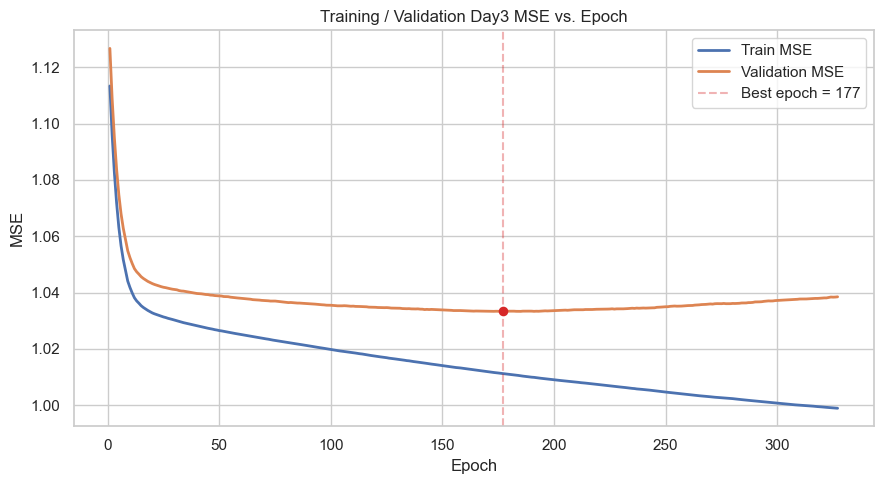

In [158]:
sns.set_theme(style="whitegrid")
epochs_ran = np.arange(1, len(train_hist) + 1)
best_epoch_plot = best_epoch if best_epoch is not None else int(np.argmin(val_hist) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, train_hist, label="Train MSE", linewidth=2)
plt.plot(epochs_ran, val_hist, label="Validation MSE", linewidth=2)
plt.axvline(best_epoch_plot, color="tab:red", linestyle="--", alpha=0.35, label=f"Best epoch = {best_epoch_plot}")
plt.scatter(best_epoch_plot, val_hist[best_epoch_plot - 1], color="tab:red", s=35, zorder=3)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training / Validation Day3 MSE vs. Epoch")
plt.legend()
plt.tight_layout()
plt.show()
